# char_07 — char_05 repeated with the dry season excluded

## Purpose

`char_05` concluded that, within the McCall collection, raw feedstock is a better
analogue for Addis filter spectra than char is — 85 % of filters, median mean-r 0.415
versus 0.278. `char_06` then showed that the dry season contains a distinct, episodic
spectral type on ~75 % of October–February filters, and that those filters are exactly
the ones sitting furthest above the 1:1 line.

That raises an obvious worry: **was the char_05 headline just the dry-season anomaly?**
If the raw-beats-char result is carried entirely by ~79 unusual filters, it is a
statement about that anomaly, not about Addis aerosol generally.

This notebook repeats char_05 on the **134 Belg and Kiremt filters only** and reports
what survives.

## Two ways to exclude, and why both are shown

| Rule | Removes | Keeps |
|---|---|---|
| **Calendar** (primary — what was asked) | all Oct–Feb filters | 134 |
| **Anomaly-based** (`char_06` mixture) | the low-similarity component, wherever it falls | 141 |

These are not the same set. `char_06` found ~26 dry-season filters that behave perfectly
normally, and 19 wet-season filters that do not. The calendar rule is the primary result
because it is the question asked and it uses no information from the outcome being
tested; the anomaly rule is reported alongside as a robustness check, and it is the
stricter of the two.

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from sklearn.mixture import GaussianMixture

from charcoal_spectra import (
    load_all, snv, resample, detrend, prepare, prepare_shape, shape_norm,
    ramp_score, band_area, BANDS, ADDIS_USABLE,
)
from etad_spectra import load_etad

PLOT_DIR = Path("output/plots/char07")
TABLE_DIR = Path("output/tables/char07")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"

SEASON_COLORS = {
    "Dry Season": "#E67E22",
    "Belg Rainy Season": "#27AE60",
    "Kiremt Rainy Season": "#3498DB",
}
SEASON_MAP = {
    "Dry (Oct-Feb)": "Dry Season",
    "Belg (Mar-May)": "Belg Rainy Season",
    "Kiremt (Jun-Sep)": "Kiremt Rainy Season",
}

ADDIS_PREP = ("Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
              "→ linear detrend → SNV   ·   McCall: as published → detrend → SNV")


def stamp(fig, text=ADDIS_PREP):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)


GRID_WIDE = np.arange(650.0, 3500.0 + 1e-9, 2.0)
GRID = np.arange(1430.0, 3500.0 + 1e-9, 2.0)

## Load, score, and define the exclusions

Identical preprocessing and scoring to `char_05`, so any difference below comes from the
filter subset and nothing else.

In [2]:
sets = load_all()
mc_meta = pd.concat(
    [sets["mccall_multi"].meta, sets["mccall_barley"].meta], ignore_index=True)
X_mc_wide = snv(detrend(np.vstack([
    resample(sets["mccall_multi"].X, sets["mccall_multi"].wn, GRID_WIDE),
    resample(sets["mccall_barley"].X, sets["mccall_barley"].wn, GRID_WIDE)]), GRID_WIDE))
_mc_narrow = np.vstack([
    resample(sets["mccall_multi"].X, sets["mccall_multi"].wn, GRID),
    resample(sets["mccall_barley"].X, sets["mccall_barley"].wn, GRID)])
X_mc = snv(detrend(_mc_narrow, GRID))
# Companion (unit-area) form for the overlay figures; statistics stay on SNV.
X_mc_s = shape_norm(detrend(_mc_narrow, GRID), GRID)

unburned = (mc_meta["temp_c"] == 0).to_numpy()
char = (mc_meta["temp_c"] > 0).to_numpy()
FEEDSTOCKS = sorted(mc_meta.loc[unburned, "species"].unique())

etad_meta, X_etad_base, wn_etad_b = load_etad(baselined=True)
etad_meta = etad_meta.copy()
etad_meta["season_label"] = etad_meta["season"].map(SEASON_MAP)
X_addis = prepare(X_etad_base, wn_etad_b, GRID)
X_addis_shape = prepare_shape(X_etad_base, wn_etad_b, GRID)


def zrows(X):
    return (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)


R = (zrows(X_addis) @ zrows(X_mc).T) / GRID.size

season = etad_meta["season_label"].to_numpy()
is_dry = season == "Dry Season"
r_char = R[:, char].max(axis=1)
r_raw = R[:, unburned].max(axis=1)

# The char_06 anomaly classifier, refitted here so this notebook stands alone.
gm = GaussianMixture(n_components=2, random_state=RANDOM_SEED, n_init=10)
gm.fit(r_char.reshape(-1, 1))
is_anom = gm.predict(r_char.reshape(-1, 1)) == np.argsort(gm.means_.ravel())[0]

KEEP = ~is_dry                      # primary: the calendar rule
KEEP_STRICT = ~is_anom              # robustness: the anomaly rule

print(f"all filters                : {len(r_char)}")
print(f"excluded — dry season      : {is_dry.sum()}  → keeping {KEEP.sum()}")
print(f"excluded — char_06 anomaly : {is_anom.sum()}  → keeping {KEEP_STRICT.sum()}")
print(f"\noverlap of the two exclusions: {(is_dry & is_anom).sum()} filters removed by both")
print(f"  dry but NOT anomalous  : {(is_dry & ~is_anom).sum()}  (ordinary-looking dry days)")
print(f"  anomalous but NOT dry  : {(~is_dry & is_anom).sum()}  (wet-season outliers)")
display(pd.crosstab(pd.Series(season, name="season"),
                    pd.Series(np.where(is_anom, "anomalous", "normal"), name="char_06 class")))

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
all filters                : 239
excluded — dry season      : 105  → keeping 134
excluded — char_06 anomaly : 98  → keeping 141

overlap of the two exclusions: 79 filters removed by both
  dry but NOT anomalous  : 26  (ordinary-looking dry days)
  anomalous but NOT dry  : 19  (wet-season outliers)


char_06 class,anomalous,normal
season,,
Belg Rainy Season,7,54
Dry Season,79,26
Kiremt Rainy Season,12,61


## 1. Does the headline survive?

The char_05 comparison — raw feedstock versus char as an Addis analogue — recomputed on
each filter subset. `median best r` is the maximum over a group's references and so
rises with the reference count (24 unburned vs 216 char); `median mean r` does not and
is the statistic to compare on.

In [3]:
def summarize(keep, label):
    sub = R[keep]
    return {
        "subset": label,
        "filters": int(keep.sum()),
        "median best r — raw": np.median(sub[:, unburned].max(axis=1)),
        "median best r — char": np.median(sub[:, char].max(axis=1)),
        "median mean r — raw": np.median(sub[:, unburned].mean(axis=1)),
        "median mean r — char": np.median(sub[:, char].mean(axis=1)),
        "share raw > char": (sub[:, unburned].max(axis=1) > sub[:, char].max(axis=1)).mean(),
        "median delta": np.median(sub[:, unburned].max(axis=1) - sub[:, char].max(axis=1)),
    }


comparison = pd.DataFrame([
    summarize(np.ones(len(r_char), bool), "all filters (char_05)"),
    summarize(KEEP, "dry season excluded (primary)"),
    summarize(KEEP_STRICT, "char_06 anomalies excluded"),
    summarize((season == "Belg Rainy Season"), "Belg only"),
    summarize((season == "Kiremt Rainy Season"), "Kiremt only"),
]).set_index("subset").round(3)
display(comparison)
comparison.to_csv(TABLE_DIR / "headline_comparison.csv")

d_all = r_raw - r_char
w = stats.wilcoxon(d_all[KEEP])
print(f"\nWilcoxon signed-rank on (r_raw − r_char), dry season excluded: "
      f"p={w.pvalue:.2e}  (n={KEEP.sum()})")
print(f"  median delta: all filters {np.median(d_all):+.3f}  →  "
      f"non-dry {np.median(d_all[KEEP]):+.3f}")

,filters,median best r — raw,median best r — char,median mean r — raw,median mean r — char,share raw > char,median delta
subset,,,,,,,
all filters (char_05),239,0.585,0.553,0.415,0.278,0.849,0.014
dry season excluded (primary),134,0.642,0.630,0.435,0.333,0.784,0.009
char_06 anomalies excluded,141,0.655,0.637,0.458,0.343,0.787,0.009
Belg only,61,0.684,0.686,0.500,0.386,0.738,0.012
Kiremt only,73,0.616,0.615,0.405,0.306,0.822,0.008



Wilcoxon signed-rank on (r_raw − r_char), dry season excluded: p=4.14e-11  (n=134)
  median delta: all filters +0.014  →  non-dry +0.009


**The conclusion survives, but it is a much smaller effect than char_05 implied.**

Raw feedstock still beats char for **78 %** of non-dry filters (against 85 % with the dry
season in), and the count-unbiased gap persists — median mean r **0.435 vs 0.333**. The
direction is significant on a paired test.

But the *margin* was never large and it shrinks further. The median per-filter advantage
falls from **+0.014** to **+0.009**, and on best-match medians the two reference classes
are effectively tied within each remaining season (Belg 0.684 raw vs 0.686 char — char is
fractionally ahead; Kiremt 0.616 vs 0.615). The 85 % figure in char_05 counted *how often*
raw biomass wins, not *by how much*; outside the dry season the honest statement is that
raw biomass is **consistently but only marginally** the better analogue.

Note also that both references fit *better* once the dry season is removed: median best
r against char rises 0.553 → 0.630. The dry-season anomaly was suppressing agreement
with everything, not selectively favouring raw biomass.

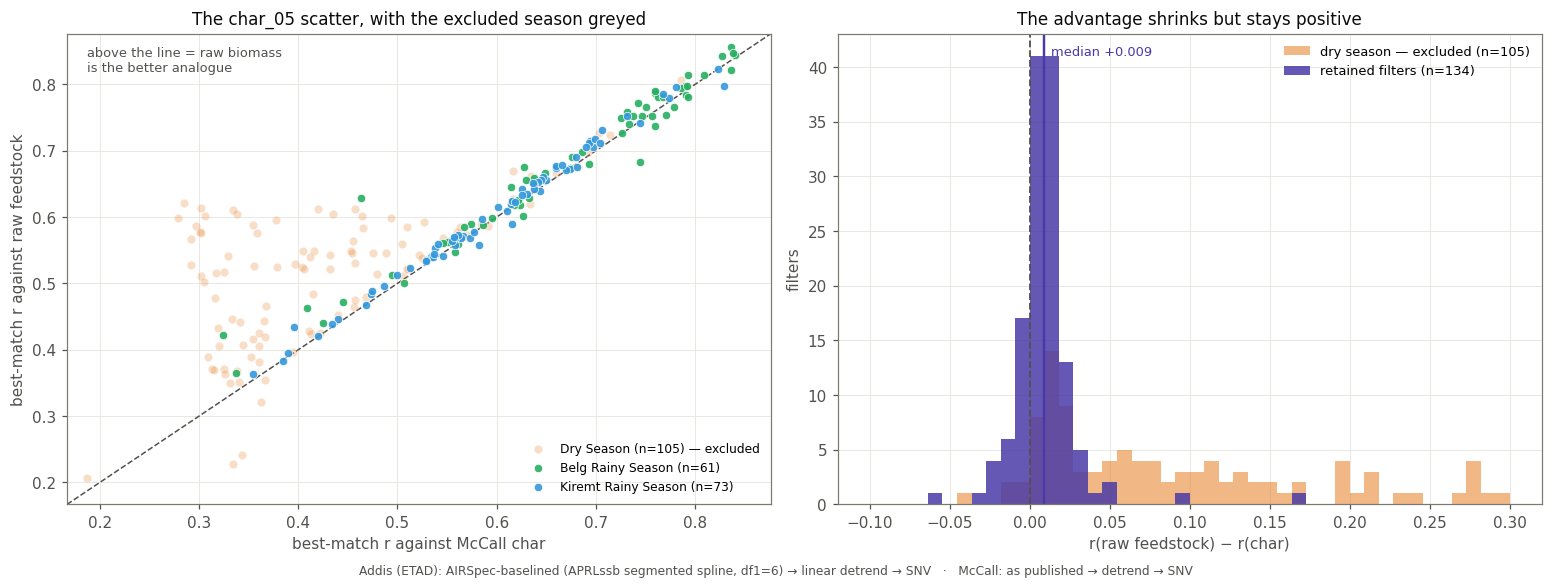

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax = axes[0]
for season_name, color in SEASON_COLORS.items():
    m = season == season_name
    excluded = season_name == "Dry Season"
    ax.scatter(r_char[m], r_raw[m], s=30, c=color, alpha=0.25 if excluded else 0.9,
               edgecolor="white", linewidth=0.5, zorder=2 if excluded else 3,
               label=f"{season_name} (n={m.sum()})" + (" — excluded" if excluded else ""))
lims = [min(r_char.min(), r_raw.min()) - 0.02, max(r_char.max(), r_raw.max()) + 0.02]
ax.plot(lims, lims, color=INK2, lw=1, ls="--", zorder=1)
ax.annotate("above the line = raw biomass\nis the better analogue",
            xy=(lims[0] + 0.02, lims[1] - 0.02), fontsize=8.5, color=INK2, va="top")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("best-match r against McCall char", color=INK2)
ax.set_ylabel("best-match r against raw feedstock", color=INK2)
ax.set_title("The char_05 scatter, with the excluded season greyed", color=INK)
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
bins = np.linspace(-0.10, 0.30, 45)
ax.hist(d_all[is_dry], bins=bins, color=SEASON_COLORS["Dry Season"], alpha=0.55,
        label=f"dry season — excluded (n={is_dry.sum()})")
ax.hist(d_all[KEEP], bins=bins, color=ADDIS_COLOR, alpha=0.85,
        label=f"retained filters (n={KEEP.sum()})")
ax.axvline(0, color=INK2, lw=1.2, ls="--")
ax.axvline(np.median(d_all[KEEP]), color=ADDIS_COLOR, lw=1.6)
ax.annotate(f"median {np.median(d_all[KEEP]):+.3f}", (np.median(d_all[KEEP]), ax.get_ylim()[1]),
            xytext=(5, -8), textcoords="offset points", va="top", fontsize=8.5,
            color=ADDIS_COLOR)
ax.set_xlabel("r(raw feedstock) − r(char)", color=INK2)
ax.set_ylabel("filters", color=INK2)
ax.set_title("The advantage shrinks but stays positive", color=INK)
ax.legend(fontsize=8.5)

stamp(fig)
fig.savefig(PLOT_DIR / "01_headline_survives.png", dpi=160, bbox_inches="tight")
plt.show()

## 2. The feedstock ordering sharpens — and it changes

This is where excluding the dry season does more than attenuate. With the anomalous
filters gone, the six raw materials separate far more cleanly, and they do not reorder
gently: grasses and straw move **up**, woods and rice husk move **down**.

,n ref,all filters,dry excluded,dry season only,change
feedstock,,,,,
barley straw,9,0.486,0.569,0.357,0.083
pine bark,3,0.378,0.454,0.253,0.076
miscanthus grass,3,0.346,0.403,0.227,0.056
chestnut wood,3,0.365,0.319,0.439,-0.045
eucalyptus bark,3,0.354,0.302,0.448,-0.052
rice husk,3,0.335,0.255,0.483,-0.080


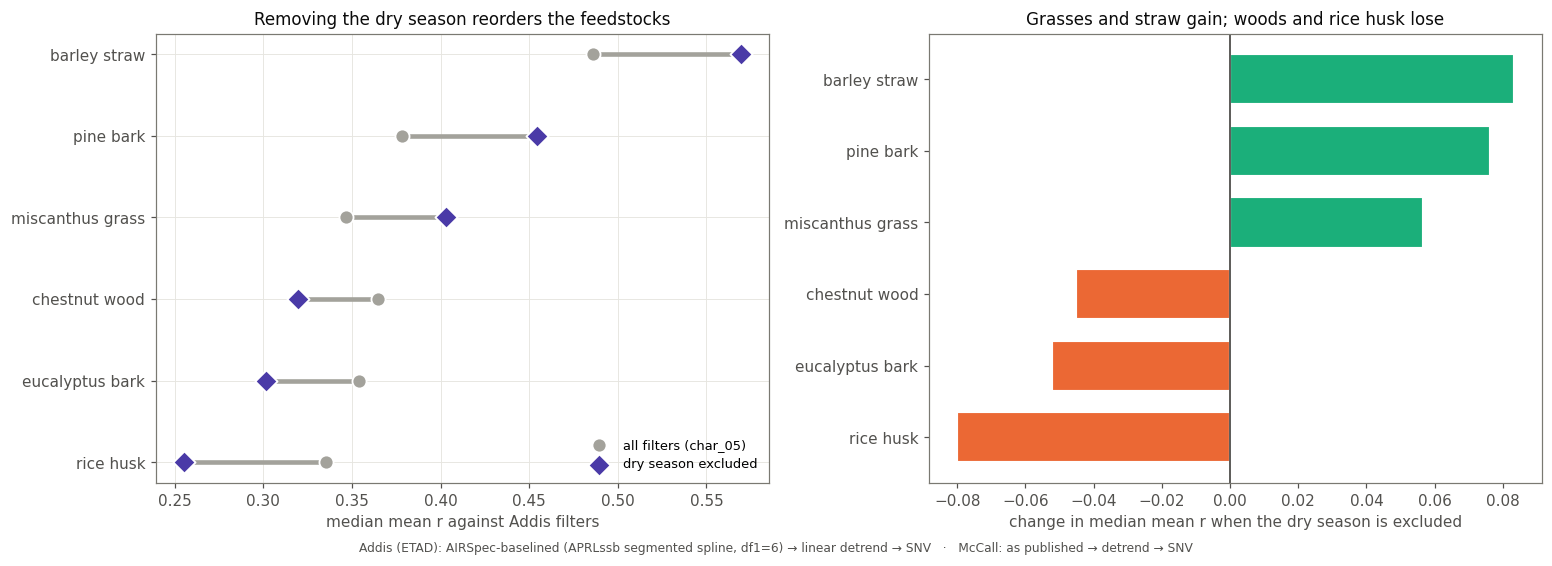

In [5]:
rows = []
for sp in FEEDSTOCKS:
    m = unburned & (mc_meta["species"] == sp).to_numpy()
    rows.append({
        "feedstock": sp, "n ref": int(m.sum()),
        "all filters": np.median(R[:, m].mean(axis=1)),
        "dry excluded": np.median(R[KEEP][:, m].mean(axis=1)),
        "dry season only": np.median(R[is_dry][:, m].mean(axis=1)),
    })
feed = pd.DataFrame(rows).set_index("feedstock")
feed["change"] = feed["dry excluded"] - feed["all filters"]
display(feed.round(3).sort_values("dry excluded", ascending=False))
feed.round(4).to_csv(TABLE_DIR / "feedstock_ranking.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

ax = axes[0]
order = feed.sort_values("dry excluded").index
ypos = np.arange(len(order))
ax.hlines(ypos, feed.loc[order, "all filters"], feed.loc[order, "dry excluded"],
          color=MUTED, lw=3, zorder=1)
ax.scatter(feed.loc[order, "all filters"], ypos, s=85, c=MUTED, edgecolor="white",
           linewidth=1.2, zorder=3, label="all filters (char_05)")
ax.scatter(feed.loc[order, "dry excluded"], ypos, s=105, c=ADDIS_COLOR, marker="D",
           edgecolor="white", linewidth=1.2, zorder=4, label="dry season excluded")
ax.set_yticks(ypos); ax.set_yticklabels(order)
ax.set_xlabel("median mean r against Addis filters", color=INK2)
ax.set_title("Removing the dry season reorders the feedstocks", color=INK)
ax.legend(fontsize=8.5, loc="lower right")

ax = axes[1]
colors = [SERIES[2] if v > 0 else SERIES[1] for v in feed.loc[order, "change"]]
ax.barh(ypos, feed.loc[order, "change"], color=colors, height=0.7,
        edgecolor="white", linewidth=1.4)
ax.axvline(0, color=INK2, lw=1.2)
ax.set_yticks(ypos); ax.set_yticklabels(order)
ax.set_xlabel("change in median mean r when the dry season is excluded", color=INK2)
ax.set_title("Grasses and straw gain; woods and rice husk lose", color=INK)
ax.grid(False)

stamp(fig)
fig.savefig(PLOT_DIR / "02_feedstock_reordering.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Addis against each feedstock, dry season removed

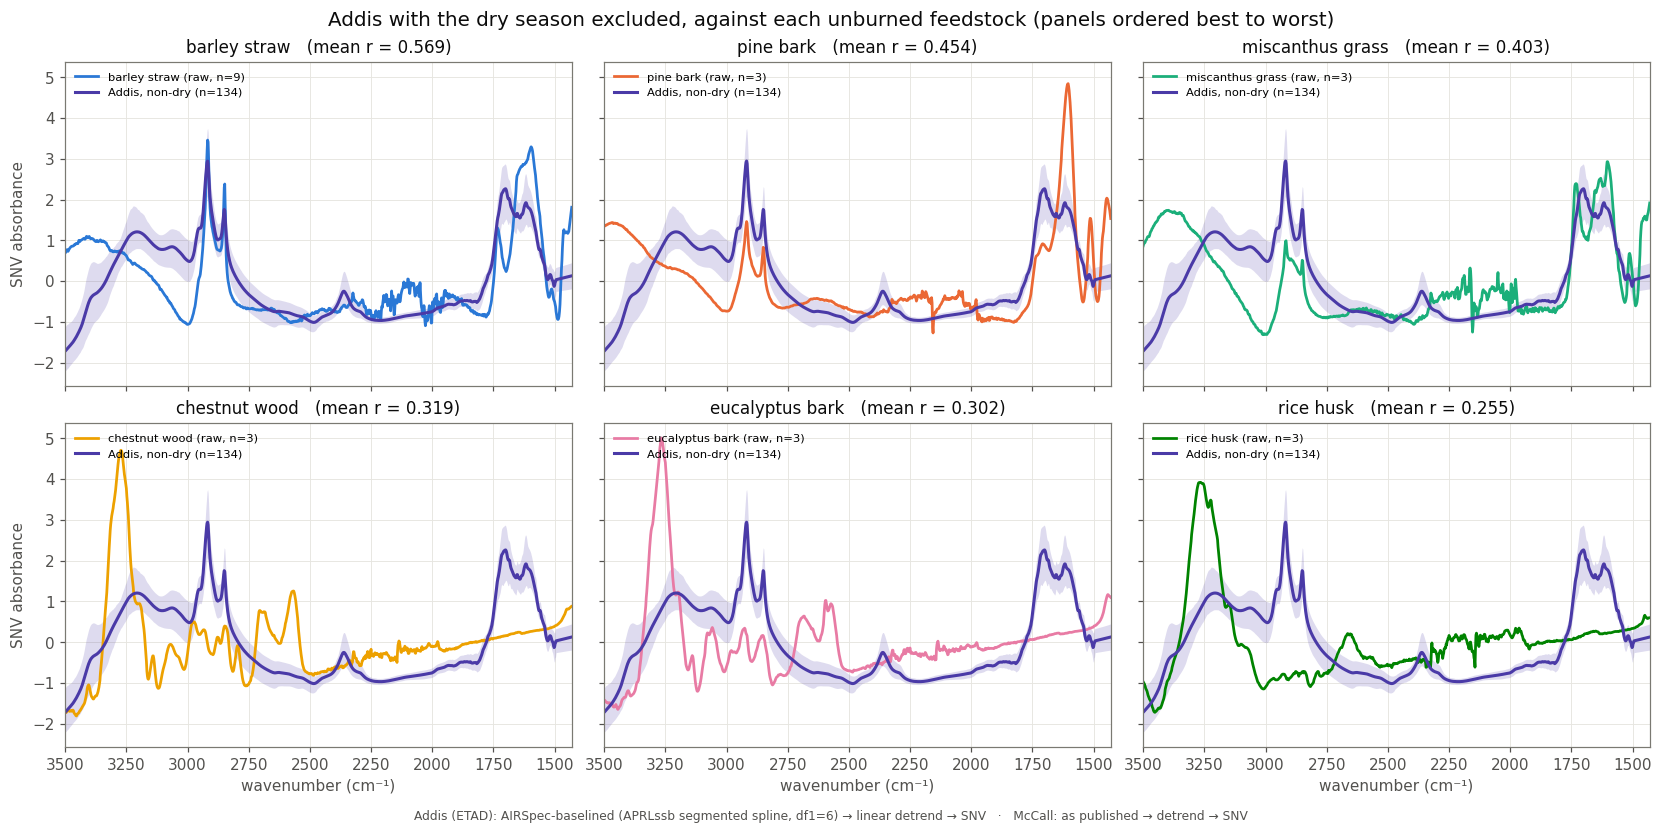

In [6]:
X_keep = X_addis[KEEP]
addis_mean = X_keep.mean(0)
addis_lo, addis_hi = np.percentile(X_keep, [10, 90], axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.2), constrained_layout=True,
                         sharex=True, sharey=True)
ranked = feed.sort_values("dry excluded", ascending=False).index
for ax, (i, sp) in zip(axes.ravel(), enumerate(ranked)):
    m = unburned & (mc_meta["species"] == sp).to_numpy()
    ax.plot(GRID, X_mc[m].mean(0), color=SERIES[i], lw=1.8,
            label=f"{sp} (raw, n={m.sum()})")
    ax.fill_between(GRID, addis_lo, addis_hi, color=ADDIS_COLOR, alpha=0.18, lw=0)
    ax.plot(GRID, addis_mean, color=ADDIS_COLOR, lw=2.0,
            label=f"Addis, non-dry (n={KEEP.sum()})")
    ax.set_xlim(GRID.max(), GRID.min())
    ax.set_title(f"{sp}   (mean r = {feed.loc[sp, 'dry excluded']:.3f})", color=INK)
    ax.legend(fontsize=7.5, loc="upper left")
for ax in axes[-1]:
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
for ax in axes[:, 0]:
    ax.set_ylabel("SNV absorbance", color=INK2)
fig.suptitle("Addis with the dry season excluded, against each unburned feedstock "
             "(panels ordered best to worst)", fontsize=13, color=INK)
stamp(fig)
fig.savefig(PLOT_DIR / "03_addis_vs_each_feedstock.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view** — the same comparison with unit-area scaling instead of SNV;
panel order and every statistic are from the SNV form and unchanged.

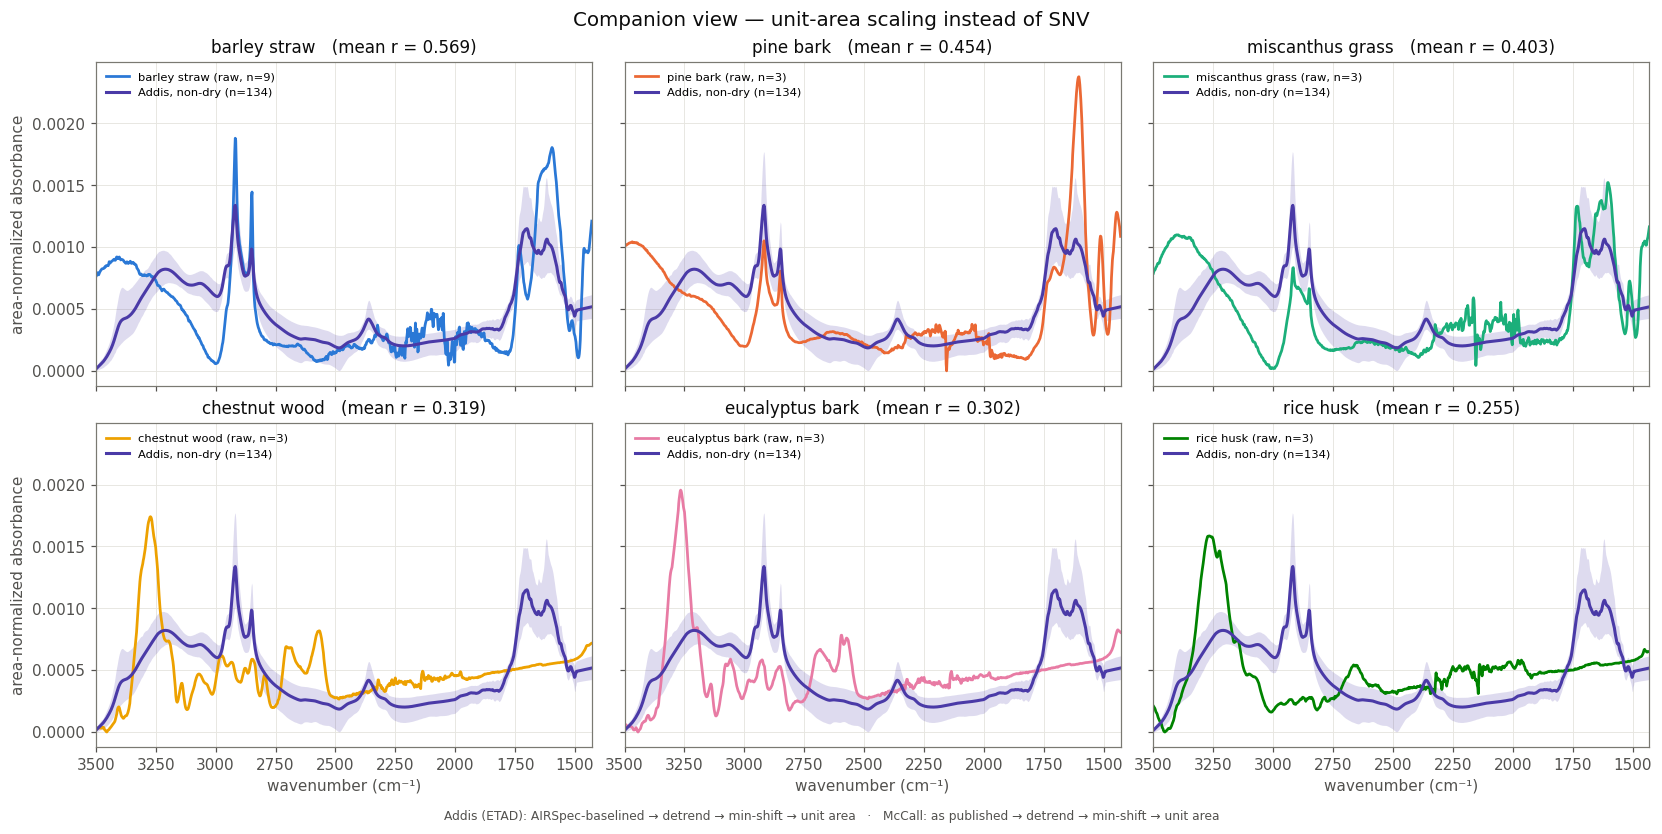

In [7]:
X_keep_s = X_addis_shape[KEEP]
addis_mean_s = X_keep_s.mean(0)
addis_lo_s, addis_hi_s = np.percentile(X_keep_s, [10, 90], axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.2), constrained_layout=True,
                         sharex=True, sharey=True)
for ax, (i, sp) in zip(axes.ravel(), enumerate(ranked)):
    m = unburned & (mc_meta["species"] == sp).to_numpy()
    ax.plot(GRID, X_mc_s[m].mean(0), color=SERIES[i], lw=1.8,
            label=f"{sp} (raw, n={m.sum()})")
    ax.fill_between(GRID, addis_lo_s, addis_hi_s, color=ADDIS_COLOR, alpha=0.18, lw=0)
    ax.plot(GRID, addis_mean_s, color=ADDIS_COLOR, lw=2.0,
            label=f"Addis, non-dry (n={KEEP.sum()})")
    ax.set_xlim(GRID.max(), GRID.min())
    ax.set_title(f"{sp}   (mean r = {feed.loc[sp, 'dry excluded']:.3f})", color=INK)
    ax.legend(fontsize=7.5, loc="upper left")
for ax in axes[-1]:
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
for ax in axes[:, 0]:
    ax.set_ylabel("area-normalized absorbance", color=INK2)
fig.suptitle("Companion view — unit-area scaling instead of SNV", fontsize=13, color=INK)
stamp(fig, "Addis (ETAD): AIRSpec-baselined → detrend → min-shift → unit area   ·   "
           "McCall: as published → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "03b_addis_vs_each_feedstock_shape.png", dpi=160,
            bbox_inches="tight")
plt.show()

## 4. What changed in the spectra themselves

The mean non-dry Addis spectrum against the mean dry-season one, and the residual each
leaves against the best raw feedstock.

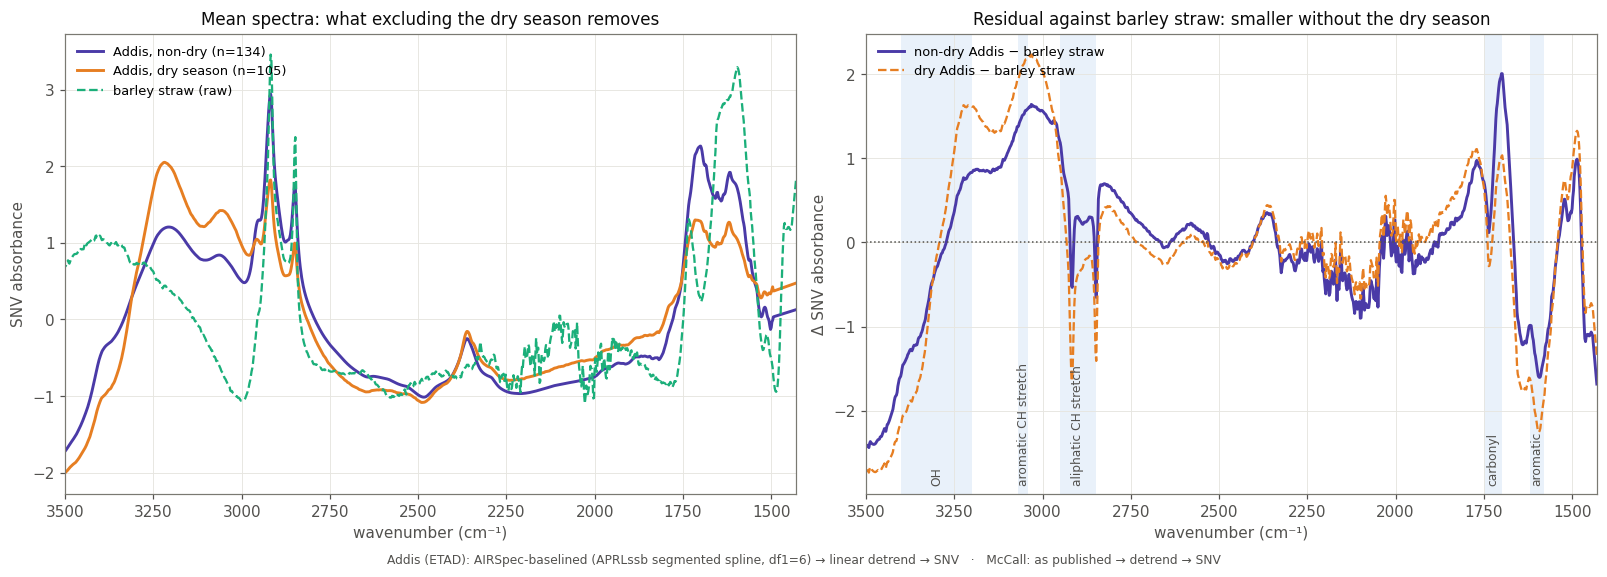

In [8]:
best_sp = feed["dry excluded"].idxmax()
ref_mean = X_mc[unburned & (mc_meta["species"] == best_sp).to_numpy()].mean(0)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.9), constrained_layout=True)

ax = axes[0]
ax.plot(GRID, X_addis[KEEP].mean(0), color=ADDIS_COLOR, lw=1.9,
        label=f"Addis, non-dry (n={KEEP.sum()})")
ax.plot(GRID, X_addis[is_dry].mean(0), color=SEASON_COLORS["Dry Season"], lw=1.9,
        label=f"Addis, dry season (n={is_dry.sum()})")
ax.plot(GRID, ref_mean, color=SERIES[2], lw=1.5, ls="--",
        label=f"{best_sp} (raw)")
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("SNV absorbance", color=INK2)
ax.set_title("Mean spectra: what excluding the dry season removes", color=INK)
ax.legend(fontsize=8.5, loc="upper left")

ax = axes[1]
ax.plot(GRID, X_addis[KEEP].mean(0) - ref_mean, color=ADDIS_COLOR, lw=1.9,
        label=f"non-dry Addis − {best_sp}")
ax.plot(GRID, X_addis[is_dry].mean(0) - ref_mean, color=SEASON_COLORS["Dry Season"],
        lw=1.5, ls="--", label=f"dry Addis − {best_sp}")
ax.axhline(0, color=INK2, lw=1, ls=":")
for name in ["OH / NH stretch", "aromatic CH stretch", "aliphatic CH stretch",
             "carbonyl C=O", "aromatic C=C"]:
    lo, hi = BANDS[name]
    if lo < GRID.min():
        continue
    ax.axvspan(lo, hi, color=SERIES[0], alpha=0.10, lw=0, zorder=0)
    ax.annotate(name.split(" /")[0].split(" C=")[0], xy=((lo + hi) / 2, ax.get_ylim()[0]),
                xytext=(0, 5), textcoords="offset points", ha="center", va="bottom",
                fontsize=8, color=INK2, rotation=90)
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("Δ SNV absorbance", color=INK2)
ax.set_title(f"Residual against {best_sp}: smaller without the dry season", color=INK)
ax.legend(fontsize=8.5, loc="upper left")

stamp(fig)
fig.savefig(PLOT_DIR / "04_spectra_and_residual.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view of the mean spectra** — same three curves, unit-area units. The
residual panel has no companion: subtraction is defined on the common SNV footing.

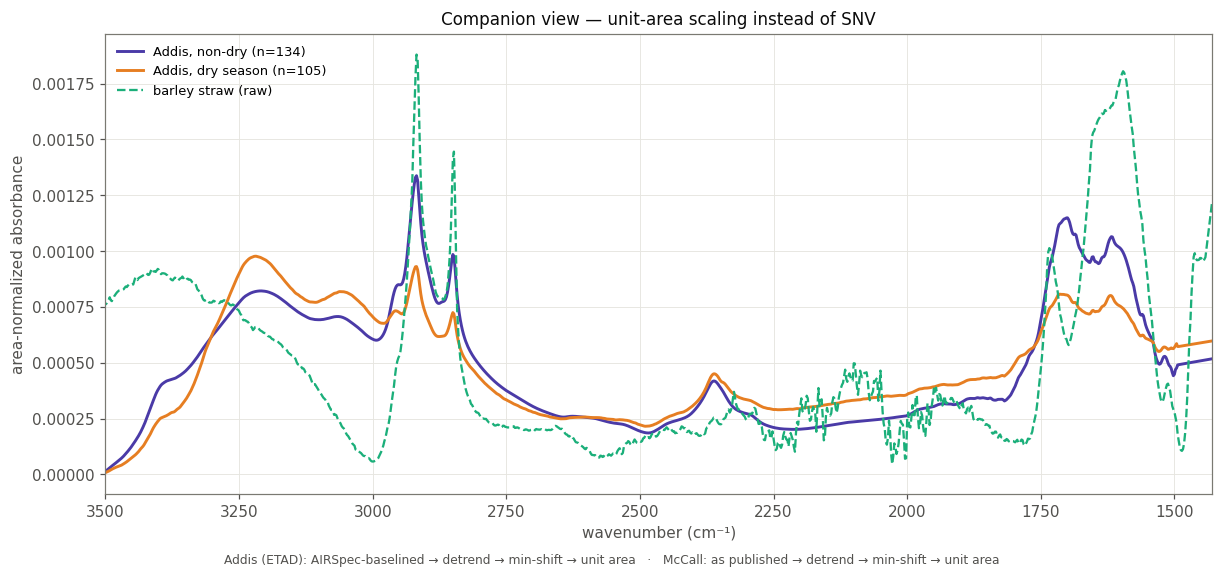

mean |residual| against barley straw:  non-dry 0.637   dry season 0.757


,Addis non-dry,Addis dry,barley straw (raw),all char
OH / NH stretch,0.42,0.52,0.75,0.50
aromatic CH stretch,0.82,1.41,-0.69,-0.16
aliphatic CH stretch,1.64,1.01,1.33,0.12
carbonyl C=O,1.69,1.09,0.70,-0.05
aromatic C=C,1.70,1.06,3.04,3.19


In [9]:
ref_mean_s = X_mc_s[unburned & (mc_meta["species"] == best_sp).to_numpy()].mean(0)

fig, ax = plt.subplots(figsize=(11, 4.9), constrained_layout=True)
ax.plot(GRID, X_addis_shape[KEEP].mean(0), color=ADDIS_COLOR, lw=1.9,
        label=f"Addis, non-dry (n={KEEP.sum()})")
ax.plot(GRID, X_addis_shape[is_dry].mean(0), color=SEASON_COLORS["Dry Season"], lw=1.9,
        label=f"Addis, dry season (n={is_dry.sum()})")
ax.plot(GRID, ref_mean_s, color=SERIES[2], lw=1.5, ls="--", label=f"{best_sp} (raw)")
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Companion view — unit-area scaling instead of SNV", color=INK)
ax.legend(fontsize=8.5, loc="upper left")
stamp(fig, "Addis (ETAD): AIRSpec-baselined → detrend → min-shift → unit area   ·   "
           "McCall: as published → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "04b_spectra_shape.png", dpi=160, bbox_inches="tight")
plt.show()

resid_nd = np.abs(X_addis[KEEP].mean(0) - ref_mean).mean()
resid_dry = np.abs(X_addis[is_dry].mean(0) - ref_mean).mean()
print(f"mean |residual| against {best_sp}:  non-dry {resid_nd:.3f}   "
      f"dry season {resid_dry:.3f}")

band_tab = pd.DataFrame({
    "Addis non-dry": {n: band_area(X_addis[KEEP], GRID, w).mean()
                      for n, w in BANDS.items() if w[0] >= GRID.min()},
    "Addis dry": {n: band_area(X_addis[is_dry], GRID, w).mean()
                  for n, w in BANDS.items() if w[0] >= GRID.min()},
    f"{best_sp} (raw)": {
        n: band_area(X_mc[unburned & (mc_meta["species"] == best_sp).to_numpy()], GRID, w).mean()
        for n, w in BANDS.items() if w[0] >= GRID.min()},
    "all char": {n: band_area(X_mc[char], GRID, w).mean()
                 for n, w in BANDS.items() if w[0] >= GRID.min()},
}).round(2)
display(band_tab)
band_tab.to_csv(TABLE_DIR / "band_levels_nondry.csv")

## 5. Robustness: does the exclusion rule matter?

The calendar rule and the `char_06` anomaly rule disagree about 45 filters. If the
conclusion depends on which is used, it is fragile.

In [10]:
robust = pd.DataFrame([
    summarize(KEEP, "calendar rule (primary)"),
    summarize(KEEP_STRICT, "char_06 anomaly rule"),
    summarize(KEEP & KEEP_STRICT, "both rules applied"),
]).set_index("subset").round(3)
display(robust)
robust.to_csv(TABLE_DIR / "robustness_exclusion_rules.csv")

feed_strict = pd.Series(
    {sp: np.median(R[KEEP_STRICT][:, unburned & (mc_meta["species"] == sp).to_numpy()].mean(axis=1))
     for sp in FEEDSTOCKS})
rank_cmp = pd.DataFrame({
    "calendar rule": feed["dry excluded"], "anomaly rule": feed_strict,
}).round(3)
rank_cmp["rank (calendar)"] = rank_cmp["calendar rule"].rank(ascending=False).astype(int)
rank_cmp["rank (anomaly)"] = rank_cmp["anomaly rule"].rank(ascending=False).astype(int)
display(rank_cmp.sort_values("rank (calendar)"))
tau = stats.kendalltau(rank_cmp["calendar rule"], rank_cmp["anomaly rule"])
print(f"feedstock ranking agreement between the two rules: Kendall τ = {tau.statistic:.2f} "
      f"(p={tau.pvalue:.3f})")

,filters,median best r — raw,median best r — char,median mean r — raw,median mean r — char,share raw > char,median delta
subset,,,,,,,
calendar rule (primary),134,0.642,0.630,0.435,0.333,0.784,0.009
char_06 anomaly rule,141,0.655,0.637,0.458,0.343,0.787,0.009
both rules applied,115,0.661,0.647,0.448,0.349,0.765,0.008


,calendar rule,anomaly rule,rank (calendar),rank (anomaly)
barley straw,0.569,0.586,1,1
pine bark,0.454,0.474,2,2
miscanthus grass,0.403,0.440,3,3
chestnut wood,0.319,0.341,4,4
eucalyptus bark,0.302,0.327,5,5
rice husk,0.255,0.279,6,6


feedstock ranking agreement between the two rules: Kendall τ = 1.00 (p=0.003)


## Takeaways

- **The char_05 headline is not an artifact of the dry season — but it was inflated by
  it.** With all 105 dry-season filters removed, raw feedstock still beats char for
  **78 %** of the remaining 134 filters (down from 85 %), the count-unbiased gap persists
  (median mean r **0.435 vs 0.333**), and the direction is significant on a paired test
  (Wilcoxon **p = 4×10⁻¹¹**). The effect is real in ordinary Addis aerosol.
- **It was always a small margin, and char_05 obscured that.** The median per-filter
  advantage is **+0.014** across all filters and **+0.009** without the dry season — and
  on best-match medians the two references are tied within each remaining season. The
  85 % statistic counted how often raw biomass wins, not by how much. "Consistently but
  marginally better" is the defensible phrasing; char_05's invited something stronger.
- **Everything fits better once the dry season is gone**, which is the clearest sign the
  anomaly was noise rather than signal for this question: median best r against char
  rises **0.553 → 0.630** and against raw feedstock **0.585 → 0.642**. The dry-season
  filters were suppressing agreement with *both* references, not selectively favouring
  raw biomass.
- **The most interesting result is the feedstock reordering, and it is a genuine
  compositional flip.** Excluding the dry season moves grasses and straw **up** (barley
  straw +0.083 to 0.569, pine bark +0.076, miscanthus +0.057) and woods and husk **down**
  (rice husk −0.080, eucalyptus −0.052, chestnut −0.045). The dry-season-only column runs
  the *opposite* order — rice husk (0.483), eucalyptus (0.448) and chestnut (0.439) are
  its best analogues, barley straw and miscanthus its worst. So the two regimes do not
  just differ in match quality; they resemble different plant material.
- **This is robust to how the exclusion is defined.** The calendar rule and the `char_06`
  anomaly rule disagree about 45 individual filters, yet give the same headline
  (78.4 % vs 78.7 %, identical median delta) and **identical feedstock rankings**
  (Kendall τ = **1.00**). Applying both together changes nothing material.

**What this does not license.** The absolute agreement is still poor — median best r
≈ 0.64 against references that match each other at r ≈ 0.99 — so none of these materials
is a good model for an Addis filter. The feedstock ordering is suggestive of grass and
straw over wood in the non-dry aerosol, but it rests on 3 replicates per feedstock (9 for
barley straw, which is also the winner — the one place the thin reference could be
flattering the result), on bulk ATR rather than filter deposits, and on a window that
excludes the C–O fingerprint where plant material is most distinguishable. Treat the
ordering as a hypothesis for a better-designed reference set, not a source attribution.